In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pypsa

In [ ]:
import os
import sys

# Add the scripts/pypsa-de directory to the path
scripts_path = os.path.join(os.path.dirname(os.getcwd()), 'scripts', 'pypsa-de')
sys.path.append(scripts_path)

from flexibility_utils import tech_colors

In [2]:
f = "/home/julian-geis/Documents/06_PhD/02Flexibility/runs/"
run = "20251015-flex-scenario-update-27cl-3h" # "20251013_flex-scenarios-temporal-industry-load-27cl-3h"
scenarios = ["LowFlex", "MediumFlex", "HighFlex"]
years = [2025, 2035, 2045]

In [3]:
networks = {}
for scenario in scenarios:
    for year in years:
        fn = f"{f}/{run}/{scenario}/networks/base_s_27__none_{year}.nc"
        networks[(scenario, year)] = pypsa.Network(fn)

INFO:pypsa.network.io:New version 1.0.0 available! (Current: 0.35.1)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.network.io:New version 1.0.0 available! (Current: 0.35.1)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.network.io:New version 1.0.0 available! (Current: 0.35.1)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.network.io:New version 1.0.0 available! (Current: 0.35.1)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.network.io:New version 1.0.0 available! (Current: 0.35.1)
INFO:pypsa.network.io:Imported network 'Unn

In [4]:
# load variables
results = {}
for scenario in scenarios:
        df = (
        pd.read_excel(
            f"{f}/{run}/{scenario}/ariadne/exported_variables_full.xlsx",
            index_col=list(range(5)),
            # index_col=["Model", "Scenario", "Region", "Variable", "Unit"],
            sheet_name="data",
        )
        .groupby(["Variable", "Unit"], dropna=False)
        .sum()
        ).round(5)
        results[scenario] = df

# Functions

In [ ]:
def plot_variable(variable_name, results, scenarios, unit=None):

    fig, ax = plt.subplots(figsize=(6, 4))

    for scenario in scenarios:
        data = results[scenario].loc[variable_name]

        if (unit is None) & (data.index[0] is not None):
            unit = data.index[0]
        elif unit is None:
            unit = "Unspecified unit"

        years = [int(col) for col in data.columns]
        ax.plot(years, data.values[0], marker='*', label=scenario, linewidth=2, markersize=8)
        
        # Set x-axis to show only the years in the data
        if years is not None:
            ax.set_xticks(years)
    
    ax.set_xlabel('Year')
    ax.set_ylabel(unit if unit and pd.notna(unit) else 'Value')
    ax.set_title(variable_name)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Start

In [46]:
kwargs = {
    "groupby": ["bus", "carrier"],
    "at_port": True,
    "nice_names": False,
}

n = networks[("MediumFlex", 2035)]

cf_electricity = (
    n.statistics.capacity_factor(
        bus_carrier=["AC", "low voltage"],
        **kwargs,
    )
    .filter(like="DE")
    .groupby("carrier")
    .sum()
)

In [47]:
cf_electricity[cf_electricity.index.str.contains('CCGT|OCGT|gas|H2 retrofit|H2 turbine|H2 CHP', case=False)]

carrier
CCGT                        1.282380
H2 CCGT                     1.912318
H2 OCGT                     0.183124
H2 turbine                  0.117148
OCGT                        0.029021
urban central H2 CHP        1.326611
urban central gas CHP       1.439615
urban central gas CHP CC    3.856119
dtype: float64

In [51]:
cf = (generation_electricity / capacities_electricity /1e3)
cf[cf.index.str.contains('CCGT|OCGT|gas|H2 retrofit|H2 turbine|H2 CHP', case=False)]

carrier
CCGT                        0.871472
H2 CCGT                     1.022322
H2 OCGT                     0.096175
H2 turbine                  0.041725
OCGT                        0.272995
urban central H2 CHP        0.622403
urban central gas CHP       0.725498
urban central gas CHP CC    1.780046
dtype: float64

In [84]:
disp_capa = capacities_electricity[capacities_electricity.index.str.contains('CCGT|OCGT|gas|H2 retrofit|H2 turbine|H2 CHP', case=False)] / 1e3
disp_gen = generation_electricity[generation_electricity.index.str.contains('CCGT|OCGT|gas|H2 retrofit|H2 turbine|H2 CHP', case=False)] / 1e6
disp_cf = disp_gen / (disp_capa * 2920) * 1e3
pd.concat([disp_capa, disp_gen, disp_cf], axis=1, keys=['Capacity [GW]', 'Generation [TWh]', 'Capacity Factor'])

,Capacity [GW],Generation [TWh],Capacity Factor
carrier,,,
CCGT,4.541821,3.958068,0.298449
H2 CCGT,0.000079,0.000081,0.350110
H2 OCGT,62.409700,6.002264,0.032937
H2 turbine,0.086312,0.003601,0.014290
OCGT,0.023310,0.006364,0.093492
urban central H2 CHP,11.447972,7.125257,0.213152
urban central gas CHP,14.654160,10.631559,0.248458
urban central gas CHP CC,0.000019,0.000034,0.609605


In [58]:
# load pkl
import pickle

fn = "/home/julian-geis/Documents/06_PhD/02Flexibility/runs/20251015-flex-scenario-update-27cl-3h/MediumFlex/flexibility/data/flexibility_contributions_raw.pkl"
with open(fn, "rb") as f:
    flexibility_data = pickle.load(f)

In [86]:
flexibility_data[2045].loc["weekly"].loc[["Supply_H2 OCGT" , "Supply_CCGT", "Supply_urban central H2 CHP", "Supply_urban central gas CHP"]]

,Contribution (TWh/year)
Technology,
Supply_H2 OCGT,2.501450
Supply_CCGT,1.272841
Supply_urban central H2 CHP,2.534395
Supply_urban central gas CHP,3.217450


In [7]:
# filter for vars
search = "Secondary Ener"
vars = results["LowFlex"].index.get_level_values("Variable").unique().to_list()
[v for v in vars if search in v]

['Price|Secondary Energy|Electricity',
 'Price|Secondary Energy|Gases',
 'Price|Secondary Energy|Gases|Biomass',
 'Price|Secondary Energy|Gases|Hydrogen',
 'Price|Secondary Energy|Gases|Natural Gas',
 'Price|Secondary Energy|Hydrogen',
 'Price|Secondary Energy|Hydrogen|Green',
 'Price|Secondary Energy|Liquids',
 'Price|Secondary Energy|Liquids|Hydrogen',
 'Secondary Energy',
 'Secondary Energy Input|Electricity|Heat',
 'Secondary Energy Input|Electricity|Hydrogen',
 'Secondary Energy Input|Electricity|Liquids',
 'Secondary Energy Input|Hydrogen|Electricity',
 'Secondary Energy Input|Hydrogen|Gases',
 'Secondary Energy Input|Hydrogen|Heat',
 'Secondary Energy Input|Hydrogen|Liquids',
 'Secondary Energy|Electricity',
 'Secondary Energy|Electricity|Biomass',
 'Secondary Energy|Electricity|Biomass|Gaseous and Liquid',
 'Secondary Energy|Electricity|Biomass|Solid',
 'Secondary Energy|Electricity|Biomass|w/ CCS',
 'Secondary Energy|Electricity|Biomass|w/o CCS',
 'Secondary Energy|Electricity

# System cost

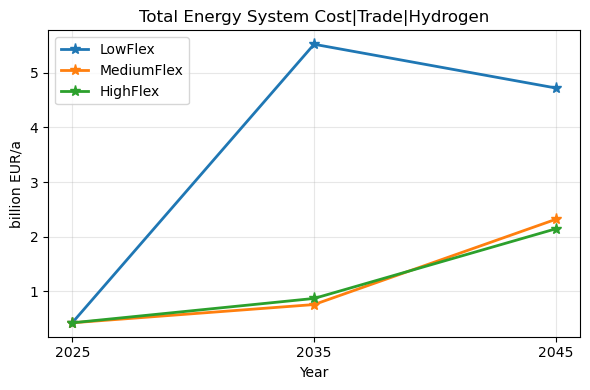

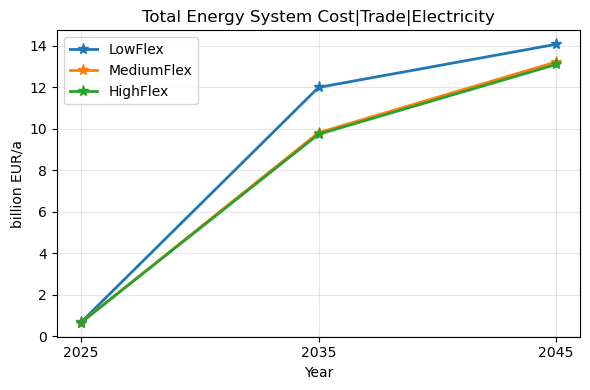

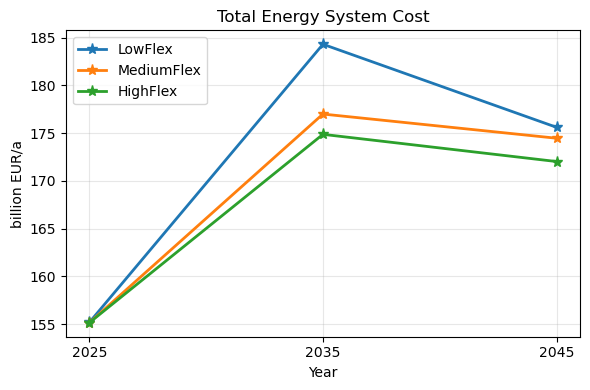

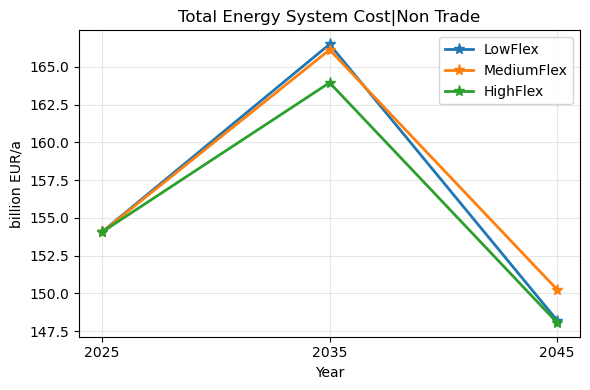

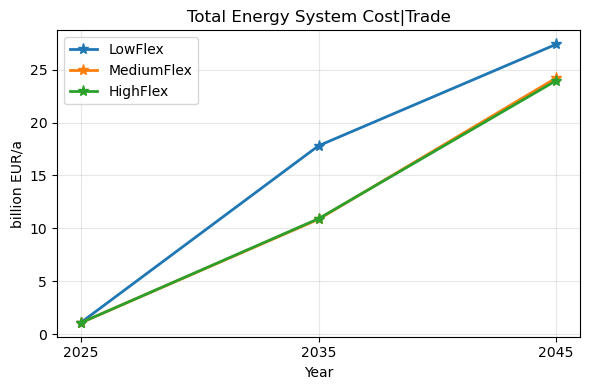

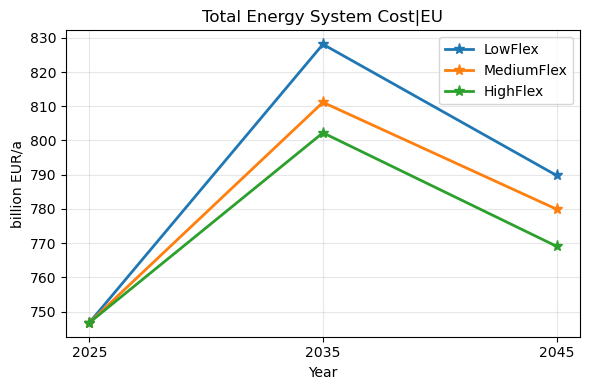

In [8]:
# System costs
plot_variable("Total Energy System Cost|Trade|Hydrogen", results, scenarios, unit="billion EUR/a")
plot_variable("Total Energy System Cost|Trade|Electricity", results, scenarios, unit="billion EUR/a")
plot_variable("Total Energy System Cost", results, scenarios, unit="billion EUR/a")
plot_variable("Total Energy System Cost|Non Trade", results, scenarios, unit="billion EUR/a")
plot_variable("Total Energy System Cost|Trade", results, scenarios, unit="billion EUR/a")
plot_variable("Total Energy System Cost|EU", results, scenarios, unit="billion EUR/a")


- system costs increase but not significantly
- import dependency is not clearly higher
- overall trade costs seem to be even lower for NoFlex atm (imports less hydrogen)

# Capacity

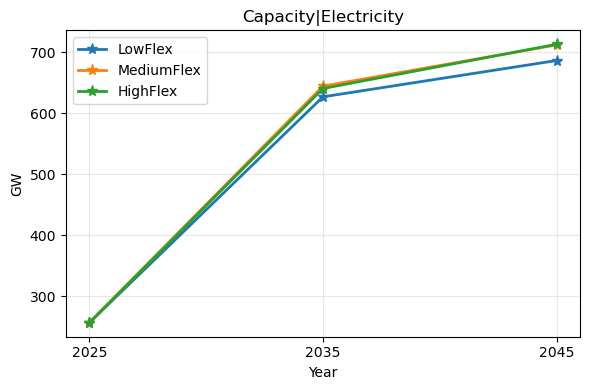

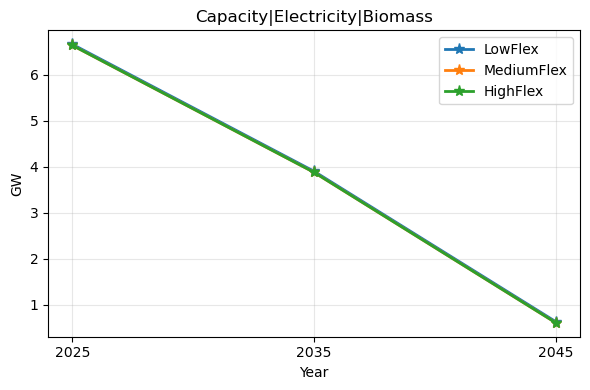

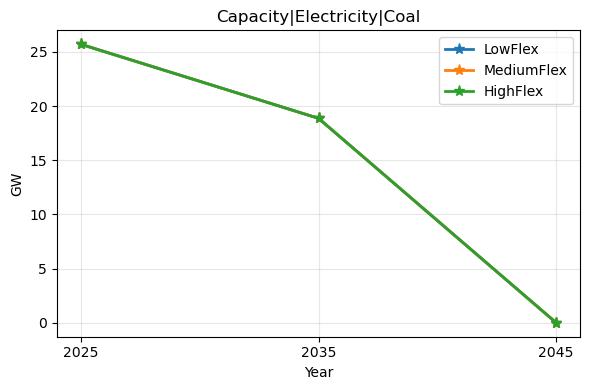

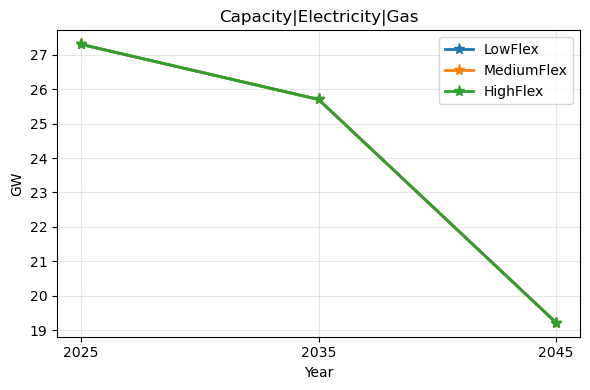

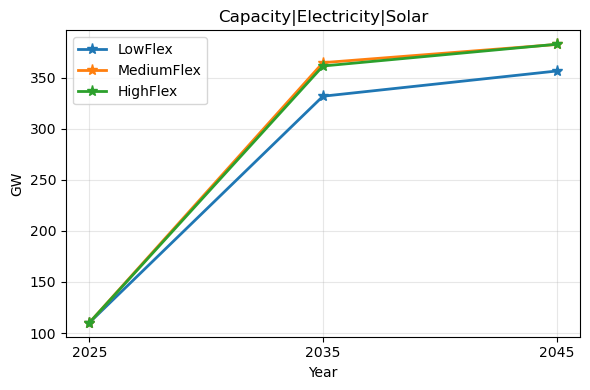

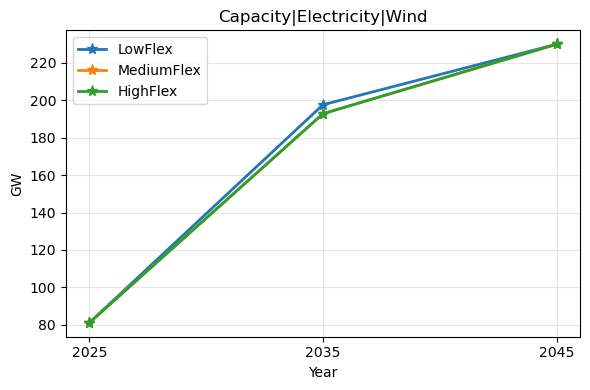

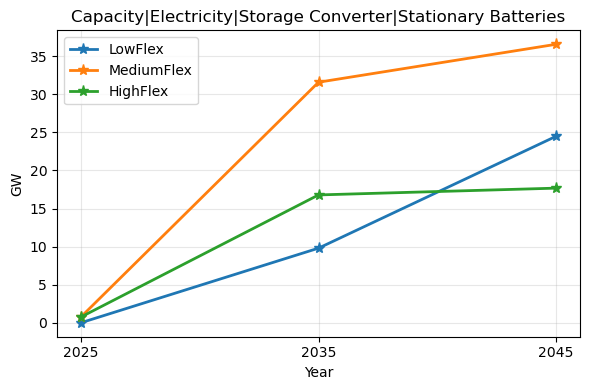

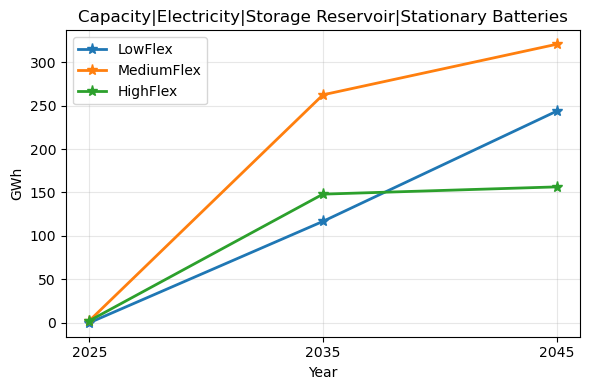

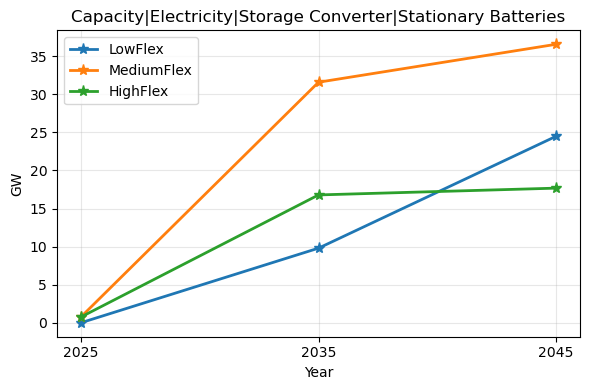

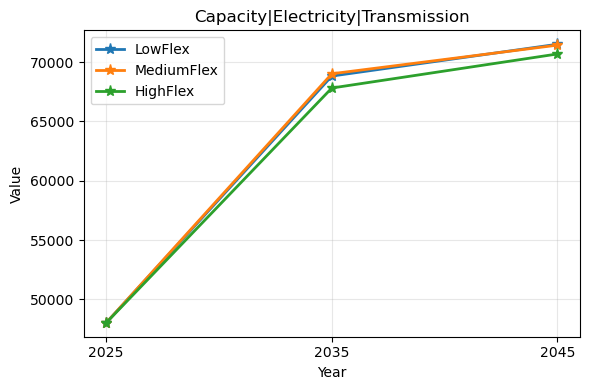

In [9]:
plot_variable("Capacity|Electricity", results, scenarios)
plot_variable("Capacity|Electricity|Biomass", results, scenarios)
plot_variable("Capacity|Electricity|Coal", results, scenarios)
plot_variable("Capacity|Electricity|Gas", results, scenarios)
plot_variable("Capacity|Electricity|Solar", results, scenarios)
plot_variable("Capacity|Electricity|Wind", results, scenarios)
plot_variable("Capacity|Electricity|Storage Converter|Stationary Batteries", results, scenarios)
plot_variable("Capacity|Electricity|Storage Reservoir|Stationary Batteries", results, scenarios)
plot_variable("Capacity|Electricity|Storage Converter|Stationary Batteries", results, scenarios)
plot_variable("Capacity|Electricity|Transmission", results, scenarios)



#  'Capacity|Electricity|Storage Converter',
#  'Capacity|Electricity|Storage Converter|Hydro Dam Reservoir',
#  'Capacity|Electricity|Storage Converter|Pump Hydro',
#  'Capacity|Electricity|Storage Converter|Stationary Batteries',
#  'Capacity|Electricity|Storage Converter|Vehicles',
#  'Capacity|Electricity|Storage Reservoir',
#  'Capacity|Electricity|Storage Reservoir|Hydro Dam Reservoir',
#  'Capacity|Electricity|Storage Reservoir|Pump Hydro',
#  'Capacity|Electricity|Storage Reservoir|Stationary Batteries',
#  'Capacity|Electricity|Storage Reservoir|Vehicles',
#  'Capacity|Electricity|Transmission',
#  'Capacity|Electricity|Transmission|AC',
#  'Capacity|Electricity|Transmission|AC|NEP',
#  'Capacity|Electricity|Transmission|DC',
#  'Capacity|Electricity|Transmission|DC|NEP',
#  'Capacity|Electricity|Transmission|NEP',

- capacities very similar; LowFlex has more solar
- Low Flex has highest batteries?? -> home batteries

In [82]:
kwargs = {
    "groupby": ["bus", "carrier"],
    "at_port": True,
    "nice_names": False,
}

for year in [2045]:

    n = networks[("MediumFlex", year)]

    capacities_electricity = (
        n.statistics.optimal_capacity(
            bus_carrier=["AC", "low voltage"],
            **kwargs,
        )
        .filter(like="DE")
        .groupby("carrier")
        .sum()
        .drop(
            # transmission capacities
            ["AC", "DC", "electricity distribution grid"],
            errors="ignore",
        )
    )

    print(year)
    print(capacities_electricity[capacities_electricity.index.str.contains('CCGT|OCGT|gas|H2 retrofit|H2 turbine|H2 CHP', case=False)] / 1e3)
    print()

2045
carrier
CCGT                         4.541821
H2 CCGT                      0.000079
H2 OCGT                     62.409700
H2 turbine                   0.086312
OCGT                         0.023310
urban central H2 CHP        11.447972
urban central gas CHP       14.654160
urban central gas CHP CC     0.000019
dtype: float64



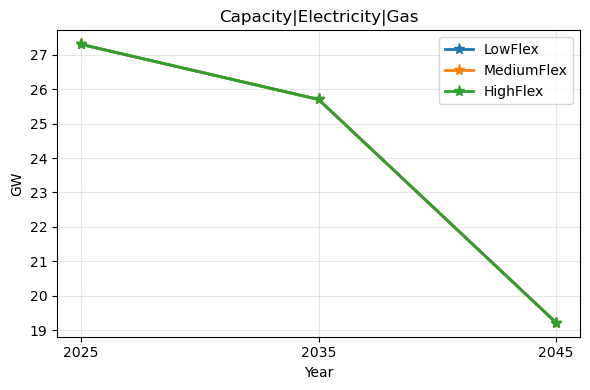

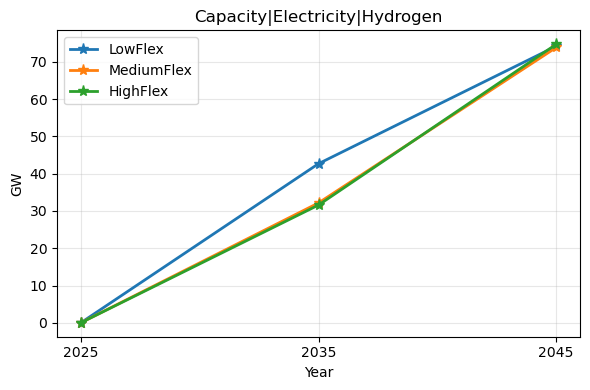

In [32]:
plot_variable("Capacity|Electricity|Gas", results, scenarios)
plot_variable("Capacity|Electricity|Hydrogen", results, scenarios)

In [83]:
for year in [2045]:

    n = networks[("MediumFlex", year)]

    generation_electricity = (
        n.statistics.supply(
            bus_carrier=["AC", "low voltage"],
            **kwargs,
        )
        .filter(like="DE")
        .groupby("carrier")
        .sum()
        .drop(
            # transmission capacities
            ["AC", "DC", "electricity distribution grid"],
            errors="ignore",
        )
    )

    print(year)
    print(generation_electricity[generation_electricity.index.str.contains('CCGT|OCGT|gas|H2 retrofit|H2 turbine|H2 CHP', case=False)] / 1e6)
    print() 

2045
carrier
CCGT                         3.958068
H2 CCGT                      0.000081
H2 OCGT                      6.002264
H2 turbine                   0.003601
OCGT                         0.006364
urban central H2 CHP         7.125257
urban central gas CHP       10.631559
urban central gas CHP CC     0.000034
dtype: float64



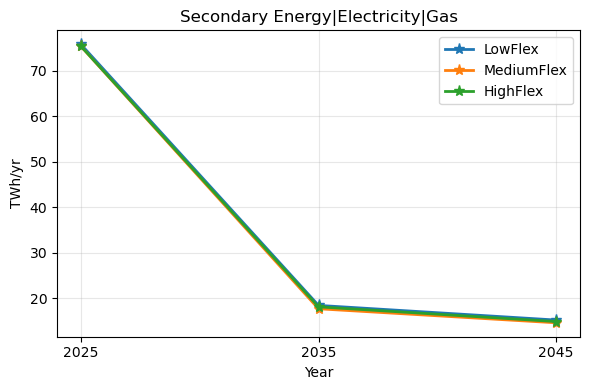

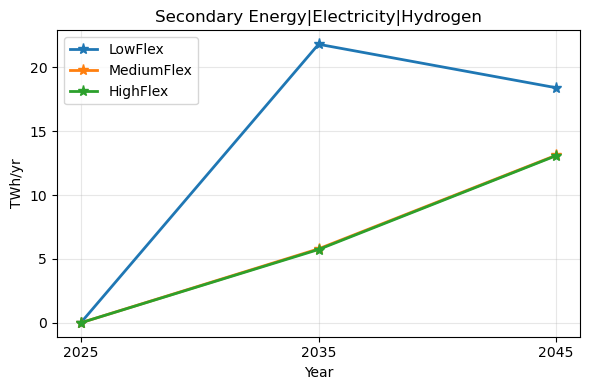

In [40]:
plot_variable("Secondary Energy|Electricity|Gas", results, scenarios)
plot_variable("Secondary Energy|Electricity|Hydrogen", results, scenarios)

In [85]:
n.links[(n.links.carrier == "H2 Electrolysis") & (n.links.bus0.str.contains("DE"))].p_nom_opt.sum() #[["efficiency", "efficiency2"]]#

33105.08167788998

In [96]:
# export capacities
kwargs = {
    "groupby": ["name","bus", "carrier"],
    "nice_names": False,
}

results_dict = {}

for year in years:
    n = networks[("MediumFlex", year)]
    capacities = (
        n.statistics.optimal_capacity(**kwargs)
        .filter(like="DE")
    )
    results_dict[year] = capacities

results = pd.concat(results_dict, axis=1)
results.columns = years  # Clean up column names
results.to_csv(f + run + "/MediumFlex_capacities_27cl_3H.csv")

In [98]:
results

2025  \
component name                                   bus                               carrier                                     
Generator DE gas primary                         DE gas primary                    gas primary                  239041.86429   
          DE oil primary                         DE oil primary                    oil primary                  199301.15933   
          DE0 0 0 onwind-2000                    DE0 0                             onwind                          603.60282   
          DE0 0 0 onwind-2005                    DE0 0                             onwind                         1203.54144   
          DE0 0 0 onwind-2010                    DE0 0                             onwind                          849.20331   
...                                                                                                                      ...   
Store     DE0 7 home battery-2045                DE0 7 home battery                home battery                          NaN   
          DE0 7 rural water tanks-2045           DE0 7 rural water tanks           rural water tanks                     NaN   
          DE0 7 urban central water pits-2045    DE0 7 urban central water pits    urban central water pits              NaN   
          DE0 7 urban central water tanks-2045   DE0 7 urban central water tanks   urban central water tanks             NaN   
          DE0 7 urban decentral water tanks-2045 DE0 7 urban decentral water tanks urban decentral water tanks           NaN   

                                                                                                                        2035  \
component name                                   bus                               carrier                                     
Generator DE gas primary                         DE gas primary                    gas primary                  139903.50439   
          DE oil primary                         DE oil primary                    oil primary                   78930.10061   
          DE0 0 0 onwind-2000                    DE0 0                             onwind                                NaN   
          DE0 0 0 onwind-2005                    DE0 0                             onwind                                NaN   
          DE0 0 0 onwind-2010                    DE0 0                             onwind                          849.20331   
...                                                                                                                      ...   
Store     DE0 7 home battery-2045                DE0 7 home battery                home battery                          NaN   
          DE0 7 rural water tanks-2045           DE0 7 rural water tanks           rural water tanks                     NaN   
          DE0 7 urban central water pits-2045    DE0 7 urban central water pits    urban central water pits              NaN   
          DE0 7 urban central water tanks-2045   DE0 7 urban central water tanks   urban central water tanks             NaN   
          DE0 7 urban decentral water tanks-2045 DE0 7 urban decentral water tanks urban decentral water tanks           NaN   

                                                                                                                       2045  
component name                                   bus                               carrier                                   
Generator DE gas primary                         DE gas primary                    gas primary                  57617.78500  
          DE oil primary                         DE oil primary                    oil primary                  26927.30833  
          DE0 0 0 onwind-2000                    DE0 0                             onwind                               NaN  
          DE0 0 0 onwind-2005                    DE0 0                             onwind                               NaN  
          DE0 0 0 onwind-2010     

In [97]:
n = networks[("MediumFlex", 2045)]
capacities = (
    n.statistics.optimal_capacity(**kwargs)
    .filter(like="DE")
)

In [90]:
capacities.loc[("Link" , , "H2 Electrolysis")]

SyntaxError: invalid syntax (3600823775.py, line 1)

In [91]:
results_dict[2045].loc[("Link" , "DE0 5", "H2 Electrolysis")]

0.01115

In [93]:
results_dict[2045].xs("H2 Electrolysis", level=2)

component  bus  
Link       DE0 0        0.00890
           DE0 1     6304.27616
           DE0 2    21698.76340
           DE0 3     5101.99563
           DE0 4        0.01105
           DE0 5        0.01115
           DE0 6        0.00808
           DE0 7        0.00731
dtype: float64

In [80]:
results.loc[("Link" , "DE0 0", "H2 Electrolysis")]

2025    0.05089
2035    0.29453
2045    0.00890
Name: (Link, DE0 0, H2 Electrolysis), dtype: float64

In [58]:
capacities = (
    n.statistics.optimal_capacity(
        **kwargs,
    )
    .filter(like="DE")
    .groupby("carrier")
    .sum()
)

In [60]:
capacities["H2 Electrolysis"] 

33105.08168

In [40]:
capacities_electricity

carrier
BEV charger                          -442590.55501
CCGT                                    4541.82079
DAC                                       -0.01312
H2 CCGT                                    0.07924
H2 Electrolysis                       -33105.08168
H2 Fuel Cell                               0.01622
H2 OCGT                                62409.70019
H2 pipeline                              -15.50043
H2 pipeline (Kernnetz)                 -1648.95069
H2 turbine                                86.31214
OCGT                                      23.31000
PHS                                     7526.22000
battery charger                       -32749.62275
battery discharger                     32749.62275
home battery charger                   -3816.59156
home battery discharger                 3816.59156
hydro                                    289.50000
methanolisation                           -0.05167
offwind-ac                              8673.52350
offwind-dc             

In [43]:
n = networks[("MediumFlex", 2045)]

capacities_heat = (
    n.statistics.optimal_capacity(
        bus_carrier=[
            "rural heat",
        ],
        **kwargs,
    )
    .filter(like="DE")
    .groupby("carrier")
    .sum()
    .drop(
        ["urban central heat vent"],
        errors="ignore",  # drop existing labels or do nothing
    )
)

# "urban decentral water tanks charger"

In [44]:
capacities_heat

carrier
rural air heat pump                 0.00706
rural biomass boiler                0.00014
rural ground heat pump           6788.54009
rural heat vent                     8.22338
rural resistive heater          16607.05955
rural water tanks charger       -9860.15646
rural water tanks discharger     9860.15646
dtype: float64

In [14]:
n = networks[("MediumFlex", 2025)]

storage_capacities = (
    n.statistics.optimal_capacity(
        storage=True,
        **kwargs,
    )
    .filter(like="DE")
    .groupby("carrier")
    .sum()
)

In [15]:
storage_capacities["H2 Store"] / 1e3 # GWh

5.9513406

In [16]:
storage_capacities

carrier
H2 Store                       5.951341e+03
PHS                            3.853079e+04
battery                        8.686130e+00
co2 stored                     3.399152e+02
gas                            2.386602e+03
home battery                   2.285777e+03
hydro                          3.000000e+05
methanol                       5.330707e+03
non-sequestered HVC            5.840179e+07
oil                            3.327915e+03
rural water tanks              8.482999e+02
urban central water pits       1.477605e+06
urban central water tanks      8.009913e+02
urban decentral water tanks    5.365769e+01
dtype: float64

In [18]:

tech_colors["Onshore wind"] = tech_colors["onwind"]
tech_colors["Offshore wind"] = tech_colors["offwind-ac"]
tech_colors["Solar"] = tech_colors["solar"]
tech_colors["Gas"] = tech_colors["OCGT"]
tech_colors["Gas CHP"] = tech_colors["OCGT"]
tech_colors["H2"] = tech_colors["H2 OCGT"]
tech_colors["H2 CHP"] = tech_colors["H2 OCGT"]
tech_colors["Pumped storage"] = tech_colors["PHS"]
tech_colors["Battery"] = tech_colors["battery discharger"]
tech_colors["Power-to-heat"] = tech_colors["urban central air heat pump"]
tech_colors["Electrolysis"] = tech_colors["H2 Electrolysis"]
tech_colors["Others"] = "grey"

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Carrier groupings
groups = {
    'Wind + Solar': {
        'Onshore wind': ['onwind'],
        'Offshore wind': ['offwind-ac', 'offwind-dc'],
        'Solar': ['solar', 'solar rooftop', 'solar-hsat']
    },
    'Dispatchable': {
        'Gas': ['OCGT', 'CCGT'],
        'Gas CHP': ['urban central gas CHP', 'urban central gas CHP CC'],
        'H2': ['H2 turbine', 'H2 OCGT'],
        'H2 CHP': ['H2 CCGT', 'urban central H2 CHP', 'H2 Fuel Cell'],
        'Others': ['coal', 'lignite', 'urban central coal CHP', 'urban central lignite CHP',
                   'solid biomass', 'urban central solid biomass CHP', 'urban central solid biomass CHP CC',
                   'waste CHP', 'waste CHP CC', 'oil', 'urban central oil CHP']
    },
    'Storage': {
        'Pumped storage': ['PHS'],
        'Battery': ['battery discharger', 'home battery discharger']
    },
    'Demand-side flex': {
        'Power-to-heat': ['rural air heat pump', 'rural ground heat pump', 'rural resistive heater',
                          'urban central air heat pump', 'urban central resistive heater',
                          'urban decentral air heat pump', 'urban decentral resistive heater'],
        'Electrolysis': ['H2 Electrolysis']
    }
}

def get_capacities(networks, scenarios, years):
    """Extract and group capacities for all scenarios and years"""
    kwargs = {"groupby": ["bus", "carrier"], "at_port": True, "nice_names": False}
    
    all_data = {}
    
    for scenario in scenarios:
        for year in years:
            n = networks[(scenario, year)]
            caps = (n.statistics.optimal_capacity(bus_carrier=["AC", "low voltage"], **kwargs)
                    .filter(like="DE").groupby("carrier").sum()
                    .drop(["AC", "DC", "electricity distribution grid"], errors="ignore"))
            
            # Group by technology
            grouped = {}
            for group_name, techs in groups.items():
                grouped[group_name] = {}
                for tech_name, carriers in techs.items():
                    val = caps[caps.index.isin(carriers)].sum()
                    grouped[group_name][tech_name] = abs(val) / 1000  # Convert to GW
            
            all_data[(scenario, year)] = grouped
    
    return all_data

def plot_capacity_comparison(data, scenarios, years, tech_colors):
    """Create stacked bar chart comparing scenarios across years"""
    fig, axes = plt.subplots(len(years), 4, figsize=(16, 4*len(years)), 
                             gridspec_kw={'wspace': 0.3, 'hspace': 0.4})
    if len(years) == 1:
        axes = axes.reshape(1, -1)
    
    group_names = list(groups.keys())
    x = np.arange(len(scenarios))
    width = 0.6
    
    for year_idx, year in enumerate(years):
        for group_idx, group_name in enumerate(group_names):
            ax = axes[year_idx, group_idx]
            
            tech_names = list(groups[group_name].keys())
            bottoms = np.zeros(len(scenarios))
            
            for tech_name in tech_names:
                values = [data[(sc, year)][group_name].get(tech_name, 0) for sc in scenarios]
                
                color = tech_colors.get(tech_name, '#CCCCCC')
                hatch = '///' if 'CHP' in tech_name else None
                
                bars = ax.bar(x, values, width, bottom=bottoms, color=color, label=tech_name, 
                             hatch=hatch, edgecolor='white' if hatch else None, linewidth=0.5)
                
                # Add value labels
                for i, (bar, val) in enumerate(zip(bars, values)):
                    if val > 1:
                        ax.text(bar.get_x() + bar.get_width()/2, bottoms[i] + val/2,
                               f'{int(val)}', ha='center', va='center', fontsize=9, 
                               color='white', weight='bold')
                
                bottoms += values
            
            # Add total on top
            for i, total in enumerate(bottoms):
                if total > 0:
                    ax.text(i, total + max(bottoms)*0.02, f'{int(total)}', 
                           ha='center', va='bottom', fontsize=10, weight='bold')
            
            # Formatting
            ax.set_xticks(x)
            ax.set_xticklabels([sc[:3].lower() for sc in scenarios])
            ax.set_ylabel('Installed capacity (GW)', fontsize=10)
            ax.set_ylim(0, max(bottoms) * 1.15)
            ax.grid(axis='y', alpha=0.3)
            
            if year_idx == 0:
                ax.set_title(group_name, fontsize=12, weight='bold')
            
            if group_idx == len(group_names) - 1:
                ax.text(1.05, 0.5, str(year), transform=ax.transAxes, 
                       rotation=270, va='center', fontsize=14, weight='bold')
            
            ax.set_xlabel('Scenario', fontsize=10)
            
            # Add legend below (only for bottom row)
            if year_idx == len(years) - 1:
                handles, labels = ax.get_legend_handles_labels()
                ax.legend(handles, labels, loc='upper center', 
                         bbox_to_anchor=(0.5, -0.15), ncol=1, fontsize=9, frameon=False)
    
    plt.tight_layout()
    return fig

/tmp/ipykernel_23798/4023615492.py:135: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



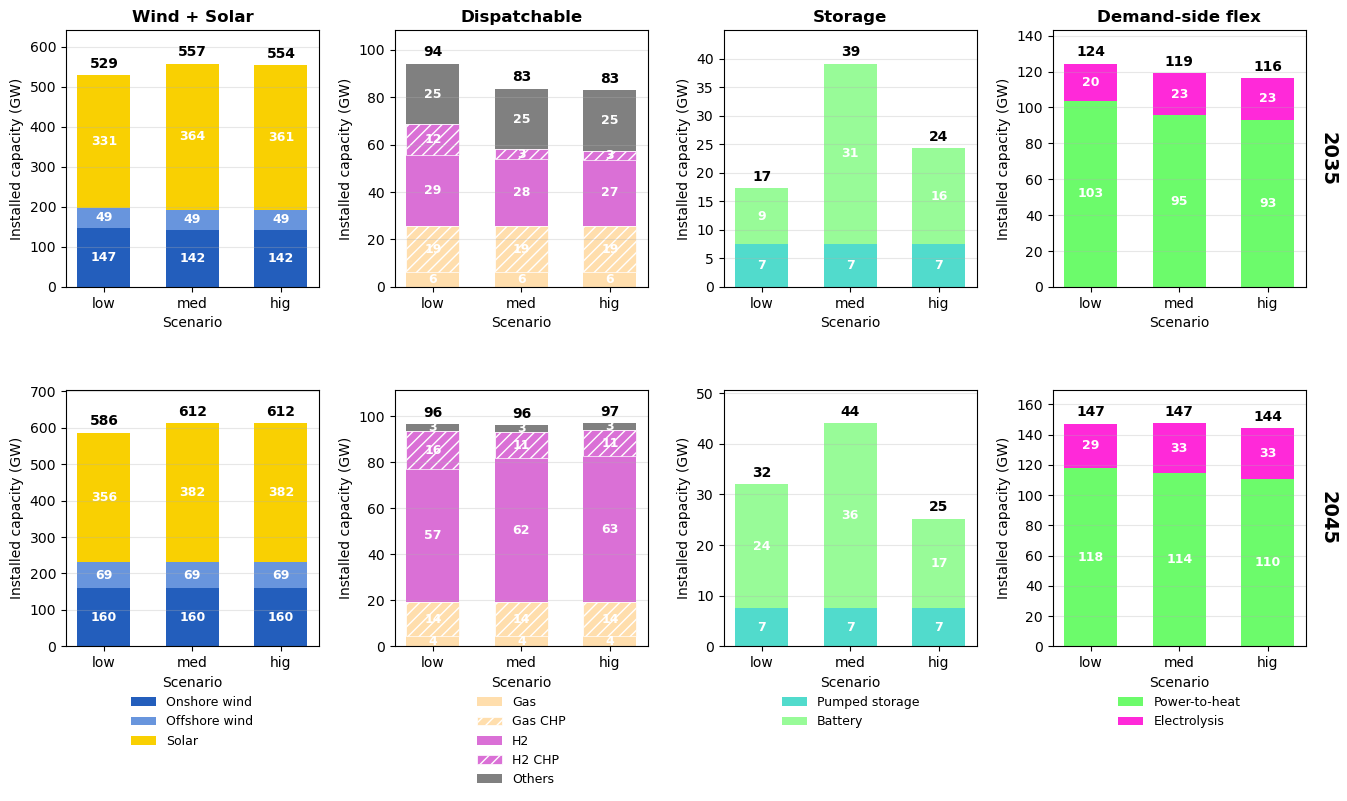

In [19]:
data = get_capacities(networks, scenarios, [2025, 2035, 2045])
fig = plot_capacity_comparison(data, scenarios, [2035, 2045], tech_colors)

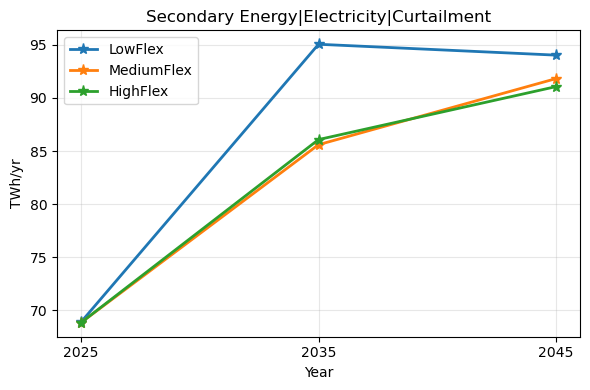

In [20]:
plot_variable("Secondary Energy|Electricity|Curtailment", results, scenarios)

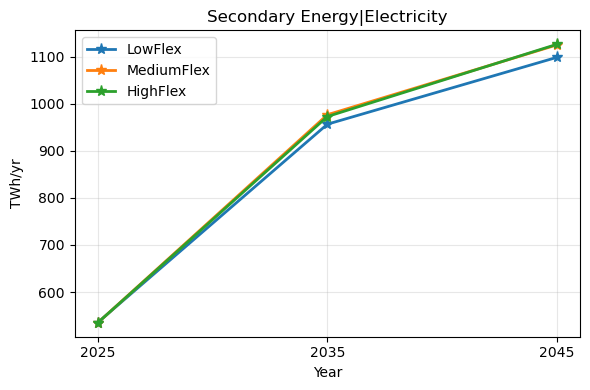

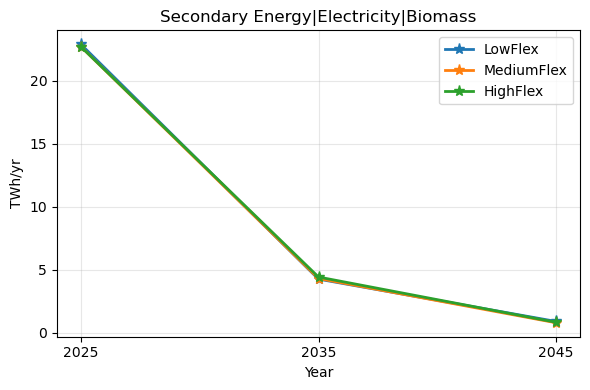

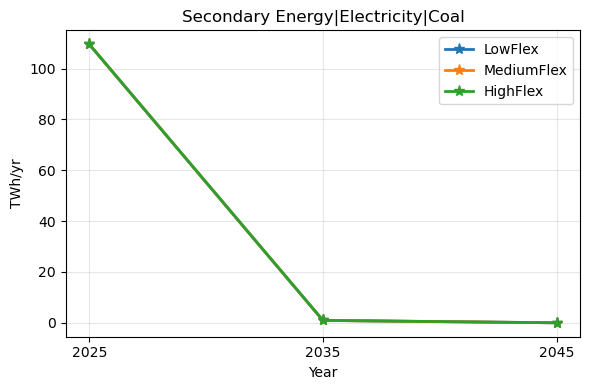

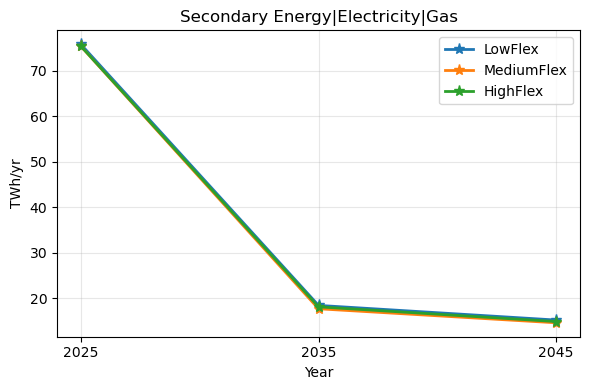

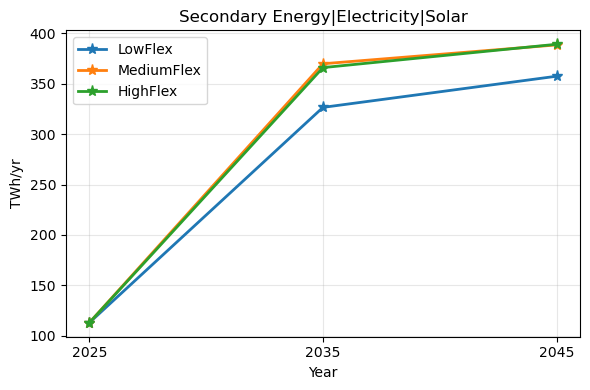

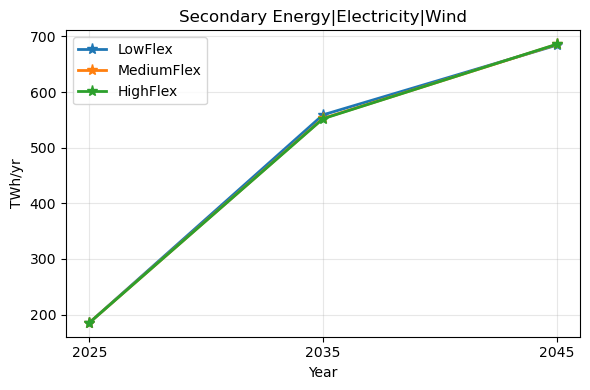

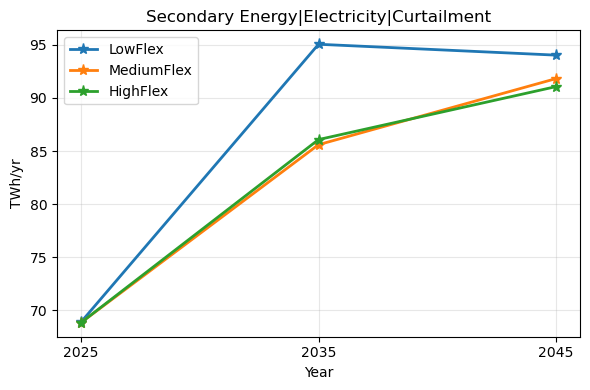

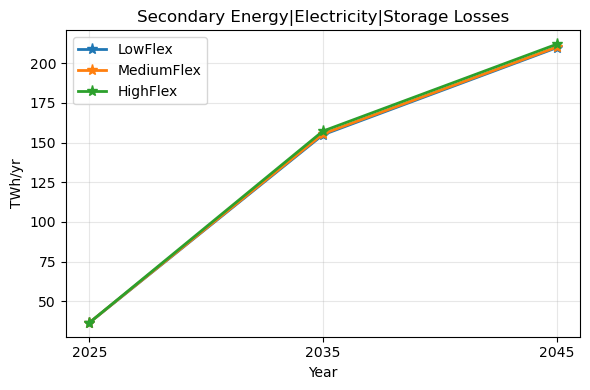

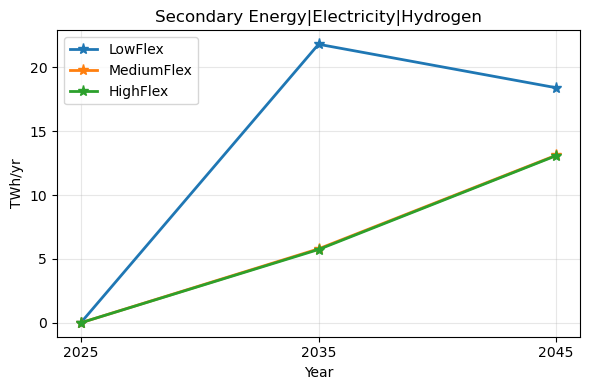

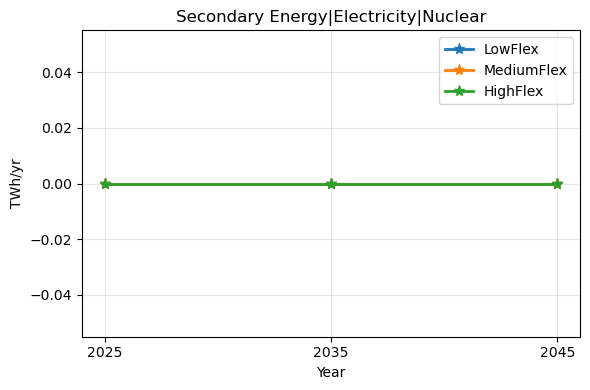

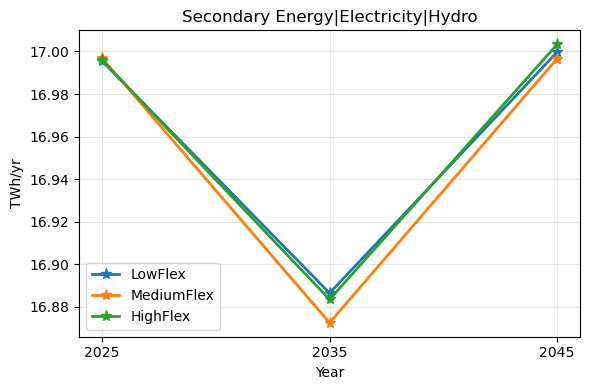

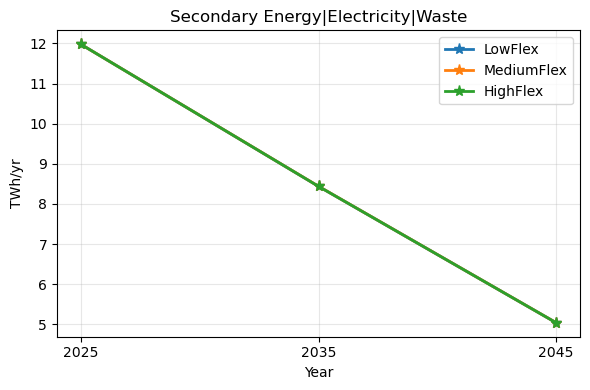

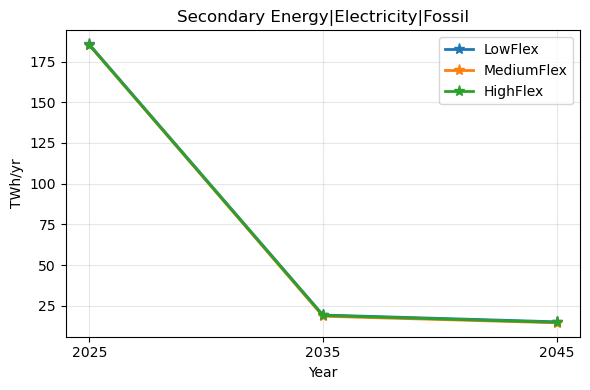

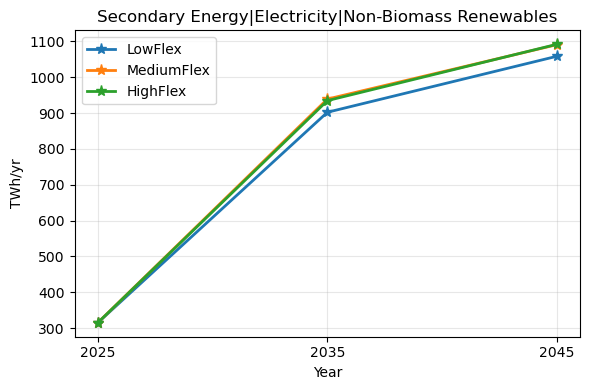

In [21]:
# Generation
plot_variable("Secondary Energy|Electricity", results, scenarios)
plot_variable("Secondary Energy|Electricity|Biomass", results, scenarios)
plot_variable("Secondary Energy|Electricity|Coal", results, scenarios)
plot_variable("Secondary Energy|Electricity|Gas", results, scenarios)
plot_variable("Secondary Energy|Electricity|Solar", results, scenarios)
plot_variable("Secondary Energy|Electricity|Wind", results, scenarios)
plot_variable("Secondary Energy|Electricity|Curtailment", results, scenarios)
plot_variable("Secondary Energy|Electricity|Storage Losses", results, scenarios)
plot_variable("Secondary Energy|Electricity|Hydrogen", results, scenarios)
plot_variable("Secondary Energy|Electricity|Nuclear", results, scenarios)
plot_variable("Secondary Energy|Electricity|Hydro", results, scenarios)
plot_variable("Secondary Energy|Electricity|Waste", results, scenarios)
plot_variable("Secondary Energy|Electricity|Fossil", results, scenarios)
plot_variable("Secondary Energy|Electricity|Non-Biomass Renewables", results, scenarios)

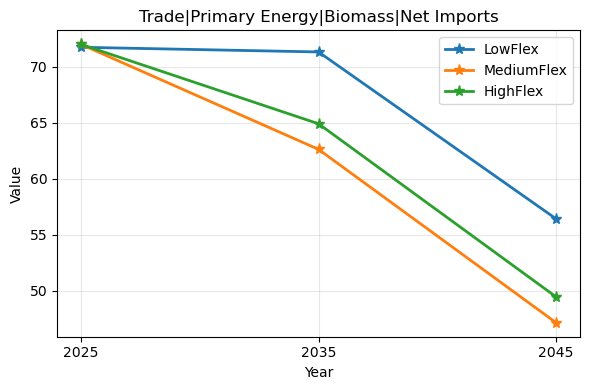

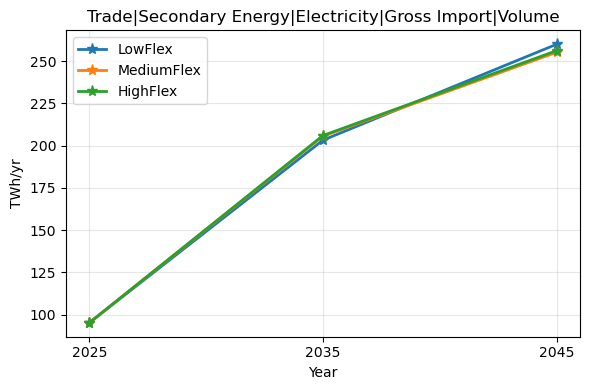

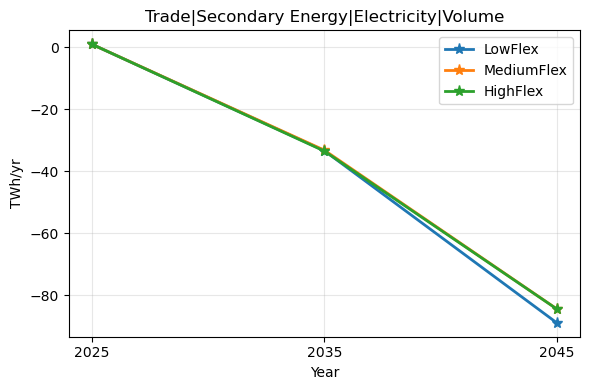

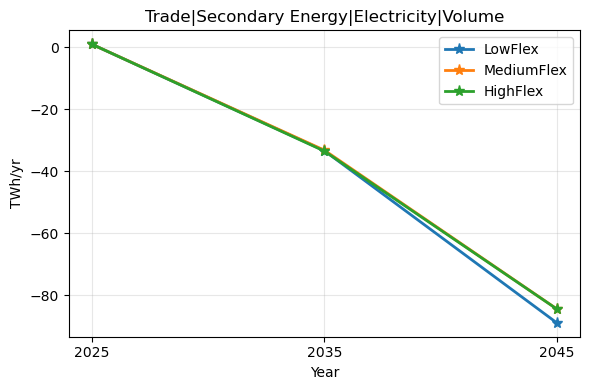

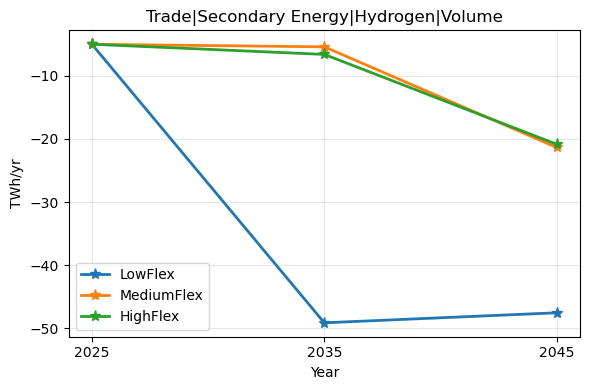

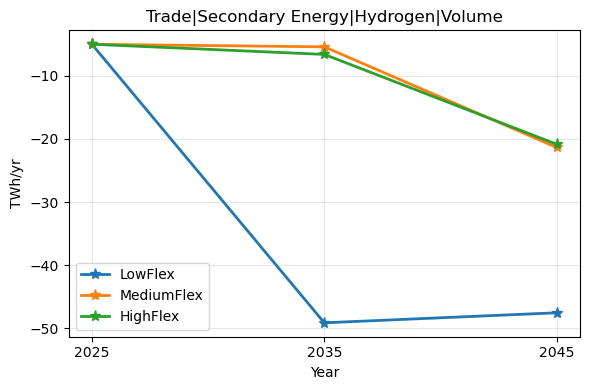

In [22]:
# Trade
plot_variable("Trade|Primary Energy|Biomass|Net Imports", results, scenarios)
plot_variable("Trade|Secondary Energy|Electricity|Gross Import|Volume", results, scenarios)
plot_variable("Trade|Secondary Energy|Electricity|Volume", results, scenarios)
plot_variable("Trade|Secondary Energy|Electricity|Volume", results, scenarios)
plot_variable("Trade|Secondary Energy|Hydrogen|Volume", results, scenarios)
plot_variable("Trade|Secondary Energy|Hydrogen|Volume", results, scenarios)

In [23]:
variable_name = "Total Energy System Cost|Trade|Hydrogen"
scenario = "LowFlex"
unit = "billion EUR/a"

data = results[scenario].loc[variable_name]


In [24]:
data

,2025,2035,2045
Unit,,,
NaN,0.42689,5.52356,4.72292


In [25]:
data.index[0]

nan

In [26]:
if data.index[0] is not None:
    unit = data.index[0]
else:
    unit = "Unspecified unit"

In [27]:
[int(col) for col in data.columns]

[2025, 2035, 2045]

In [28]:
data.values[0]

array([0.42689, 5.52356, 4.72292])